ASSIGNMENT 01-06-2026

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import STL
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

%cd src

[WinError 2] The system cannot find the file specified: 'src'
c:\Users\ASUS\Documents\aiops-nguyenduchao\w1\day-1\src


Phase 1:

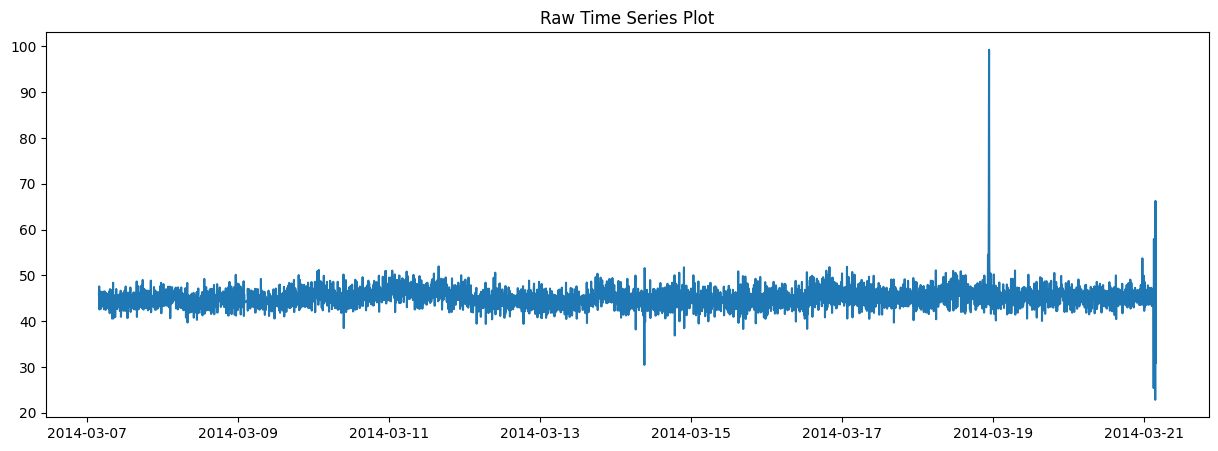

In [35]:
# Load the dataset
df = pd.read_csv('./ec2_request_latency_system_failure.csv', parse_dates=['timestamp'], index_col='timestamp')
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['value'], label='Raw Data')
plt.title('Raw Time Series Plot')
plt.show()

In [36]:
df.head()

,value
timestamp,
2014-03-07 03:41:00,45.868
2014-03-07 03:46:00,47.606
2014-03-07 03:51:00,42.580
2014-03-07 03:56:00,46.030
2014-03-07 04:01:00,44.992


In [37]:
# Compute basic statistics
print(df['value'].describe())
skewness = stats.skew(df['value'])

count    4032.000000
mean       45.155874
std         2.287089
min        22.864000
25%        43.944000
50%        45.017000
75%        46.362000
max        99.248000
Name: value, dtype: float64


Skewness của dữ liệu: 3.0618550731446446


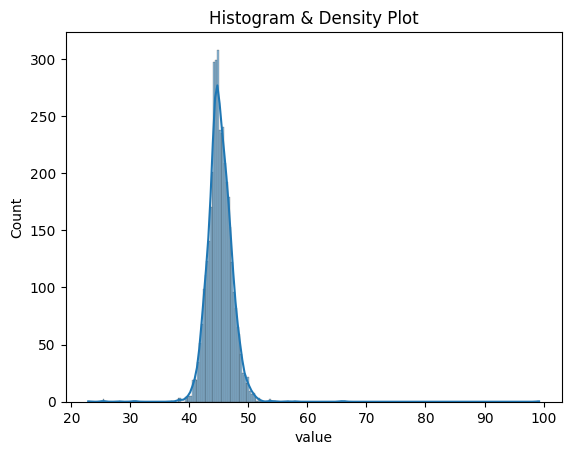

In [38]:
# Plot histogram + density
print(f"Skewness của dữ liệu: {skewness}")

sns.histplot(df['value'], kde=True)
plt.title('Histogram & Density Plot')
plt.show()

# Data bị lệch phải nặng (Right-skewed data: skewness > 1) 

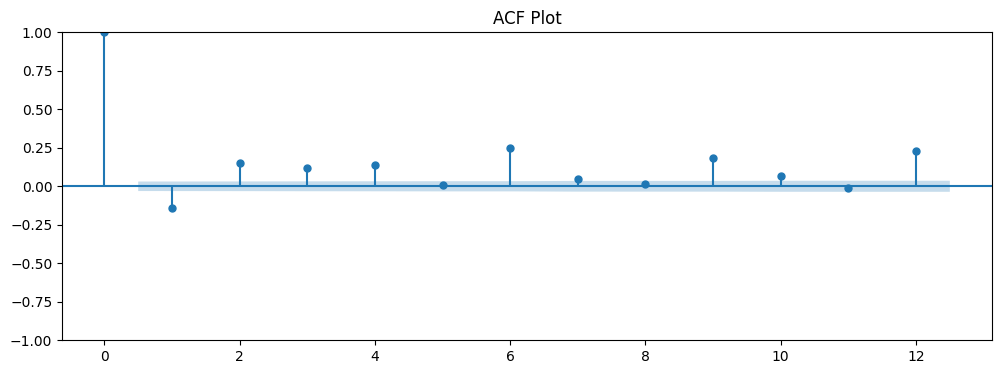

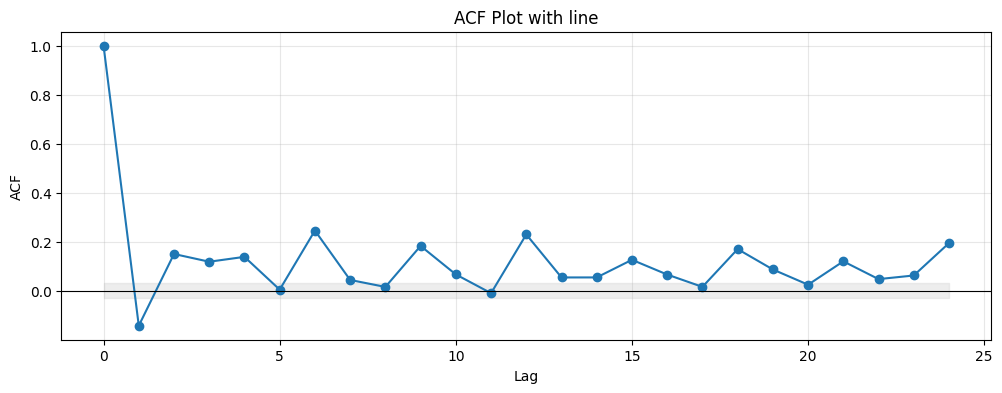

Data thuộc loại skewed, seasonal. 
Phương pháp phù hợp nhất để detect anomaly là:
    1. STL Decomposition với period=12, robust=True -> bóc tách chu kỳ.
    2. Dùng IQR trên residual, đánh dấu bất thường.


In [39]:
# Plot ACF

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['value'], lags=12, ax=ax) # 6 points = 30 min, 12 points = 1h
ax.set_title('ACF Plot')
plt.show()

acf_vals = acf(df['value'], nlags=24, fft=True)
lags = np.arange(len(acf_vals))

plt.figure(figsize=(12, 4))
plt.plot(lags, acf_vals, marker='o', linestyle='-', color='tab:blue')
plt.axhline(0, color='black', linewidth=0.8)
ci = 1.96 / np.sqrt(len(df))
plt.fill_between(lags, -ci, ci, color='lightgray', alpha=0.4)
plt.title('ACF Plot with line')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.grid(alpha=0.3)
plt.show()


# Data có seasonal ở mức vừa phải, thấy được ở mức lag = 6 hoặc lag=12 (nhưng không rõ ràng lắm).
# Dữ liệu ghi theo bước 5 phút, nên:
# lag = 6 tương ứng với 30 phút.
# lag = 12 tương ứng với 60 phút.

print(f"""Data thuộc loại skewed, seasonal. 
Phương pháp phù hợp nhất để detect anomaly là:
    1. STL Decomposition với period=12, robust=True -> bóc tách chu kỳ.
    2. Dùng IQR trên residual, đánh dấu bất thường.""")

Phase 2:

In [40]:
# Khởi tạo cột ground_truth toàn bộ bằng 0 (mặc định là bình thường)
df['ground_truth'] = 0

# Điền các mốc thời gian xảy ra sự cố thực tế Ground Truth từ NAB.
failure_timestamps = [
    "2014-03-14 09:06:00", 
    "2014-03-18 22:41:00", 
    "2014-03-21 03:01:00"
]

# Chuyển các mốc thời gian sự cố sang kiểu Datetime để khớp với Index của DataFrame
failure_timestamps = pd.to_datetime(failure_timestamps)
    
# Gán giá trị 1 (Đáp án chuẩn là Lỗi) tại đúng các mốc thời gian xảy ra sự cố
df.loc[df.index.isin(failure_timestamps), 'ground_truth'] = 1

print(f"Đã nạp xong đáp án! Số lượng điểm lỗi thực tế trong lịch sử: {df['ground_truth'].sum()}")

Đã nạp xong đáp án! Số lượng điểm lỗi thực tế trong lịch sử: 3


In [41]:
# Detector 1 — Statistical

# 1. Khởi tạo và chạy cấu hình STL với period=12 theo kết quả EDA
# Bật robust=True để các điểm outlier không làm lệch đường chu kỳ
stl = STL(df['value'], period=12, robust=True)
res = stl.fit()

# 2. Trích xuất thành phần Residual (Phần dư)
df['residual'] = res.resid

# 3. Tính toán các ngưỡng IQR trên mảng Residual
Q1 = np.percentile(df['residual'], 25)
Q3 = np.percentile(df['residual'], 75)
IQR = Q3 - Q1

# Tính ngưỡng trên và ngưỡng dưới bảo vệ hệ thống
lower_bound = Q1 - 4.5 * IQR
upper_bound = Q3 + 4.5 * IQR

# 4. Gán nhãn Anomaly dựa trên ngưỡng IQR (1 nếu là lỗi, 0 nếu bình thường)
df['anomaly_stat'] = ((df['residual'] < lower_bound) | (df['residual'] > upper_bound)).astype(int)

print(f"Số lượng điểm bất thường tìm thấy bằng STL+IQR: {df['anomaly_stat'].sum()}")

Số lượng điểm bất thường tìm thấy bằng STL+IQR: 23


=== KẾT QUẢ ĐÁNH GIÁ DETECTOR 1 ===
Precision : 0.1304
Recall    : 1.0000
F1-Score  : 0.2308


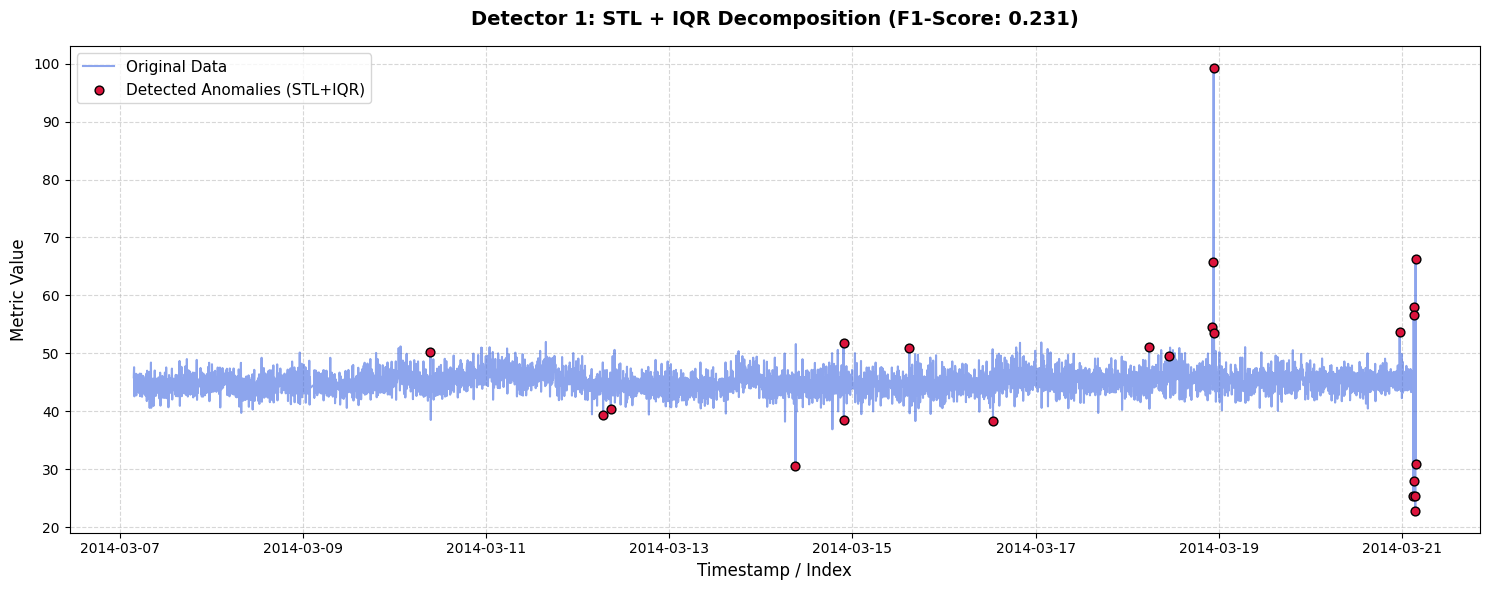

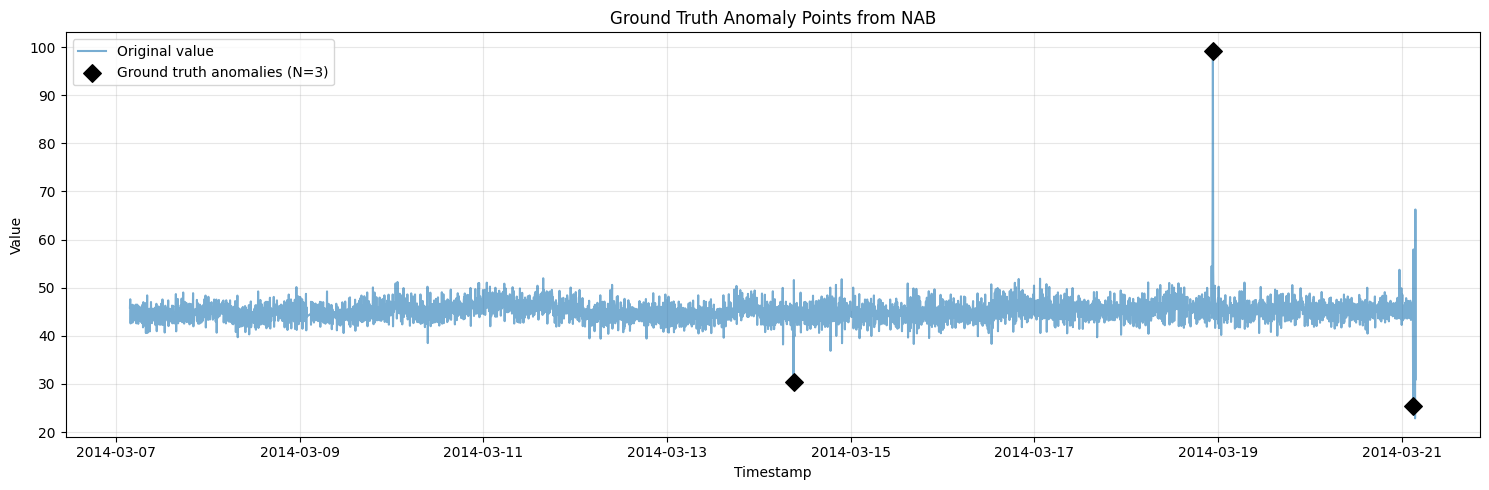

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

# ==========================================
# STEP 5: TÍNH PRECISION, RECALL, F1-SCORE

# Tính toán các chỉ số cho Detector 1 (STL + IQR)
precision_stat = precision_score(df["ground_truth"], df["anomaly_stat"])
recall_stat = recall_score(df["ground_truth"], df["anomaly_stat"])
f1_stat = f1_score(df["ground_truth"], df["anomaly_stat"])

print("=== KẾT QUẢ ĐÁNH GIÁ DETECTOR 1 ===")
print(f"Precision : {precision_stat:.4f}")
print(f"Recall    : {recall_stat:.4f}")
print(f"F1-Score  : {f1_stat:.4f}")


# ==========================================
# STEP 6: PLOT ORIGINAL SERIES + ANOMALIES

plt.figure(figsize=(15, 6))

# 1. Vẽ đường dữ liệu gốc (Original Series)
plt.plot(
    df.index,
    df["value"],
    color="royalblue",
    alpha=0.6,
    label="Original Data",
    linewidth=1.5,
)

# 2. Lọc và điểm các vị trí Anomaly do Detector 1 phát hiện (Highlight)
anomalies_stat = df[df["anomaly_stat"] == 1]
plt.scatter(
    anomalies_stat.index,
    anomalies_stat["value"],
    color="crimson",
    label="Detected Anomalies (STL+IQR)",
    edgecolor="black",
    s=40,
    zorder=3,
)

# Cấu hình hiển thị đồ thị
plt.title(
    f"Detector 1: STL + IQR Decomposition (F1-Score: {f1_stat:.3f})",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Timestamp / Index", fontsize=12)
plt.ylabel("Metric Value", fontsize=12)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

# Hiển thị đồ thị chỉn chu
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
truth_anomalies = df[df['ground_truth'] == 1]
plt.plot(df.index, df['value'], color='tab:blue', alpha=0.6, label='Original value')
plt.scatter(truth_anomalies.index, truth_anomalies['value'], color='black', marker='D', s=80,
            label=f'Ground truth anomalies (N={len(truth_anomalies)})', zorder=5)
plt.title('Ground Truth Anomaly Points from NAB')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
df

,value,ground_truth,residual,anomaly_stat
timestamp,,,,
2014-03-07 03:41:00,45.868,0,0.407880,0
2014-03-07 03:46:00,47.606,0,0.406461,0
2014-03-07 03:51:00,42.580,0,-0.815579,0
2014-03-07 03:56:00,46.030,0,0.064161,0
2014-03-07 04:01:00,44.992,0,-0.456571,0
...,...,...,...,...
2014-03-21 03:21:00,25.352,0,-18.603297,1
2014-03-21 03:26:00,38.216,0,-1.668689,0
2014-03-21 03:31:00,22.864,0,-21.859571,1


--- LOG OUTPUT CHO FILE SUBMIT.md ---
Contamination: 0.01 -> Precision: 0.071, Recall: 1.000, F1-Score: 0.133, False Alarms (FP): 39
Contamination: 0.02 -> Precision: 0.036, Recall: 1.000, F1-Score: 0.069, False Alarms (FP): 81
Contamination: 0.05 -> Precision: 0.014, Recall: 1.000, F1-Score: 0.028, False Alarms (FP): 205

[SUCCESS]


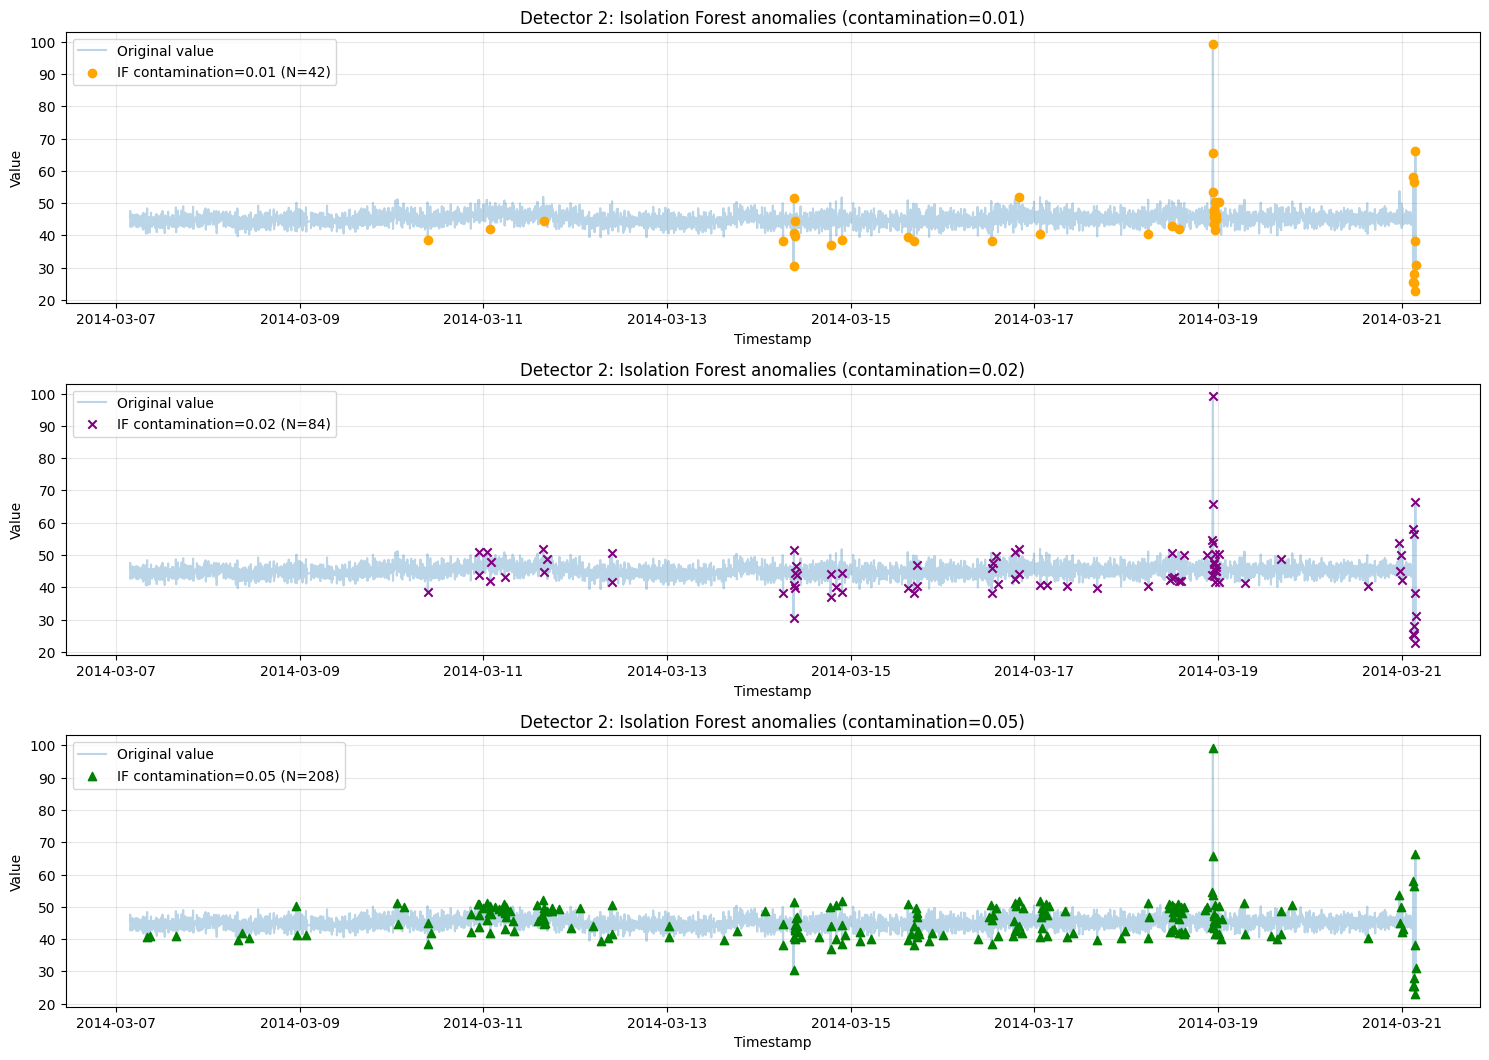

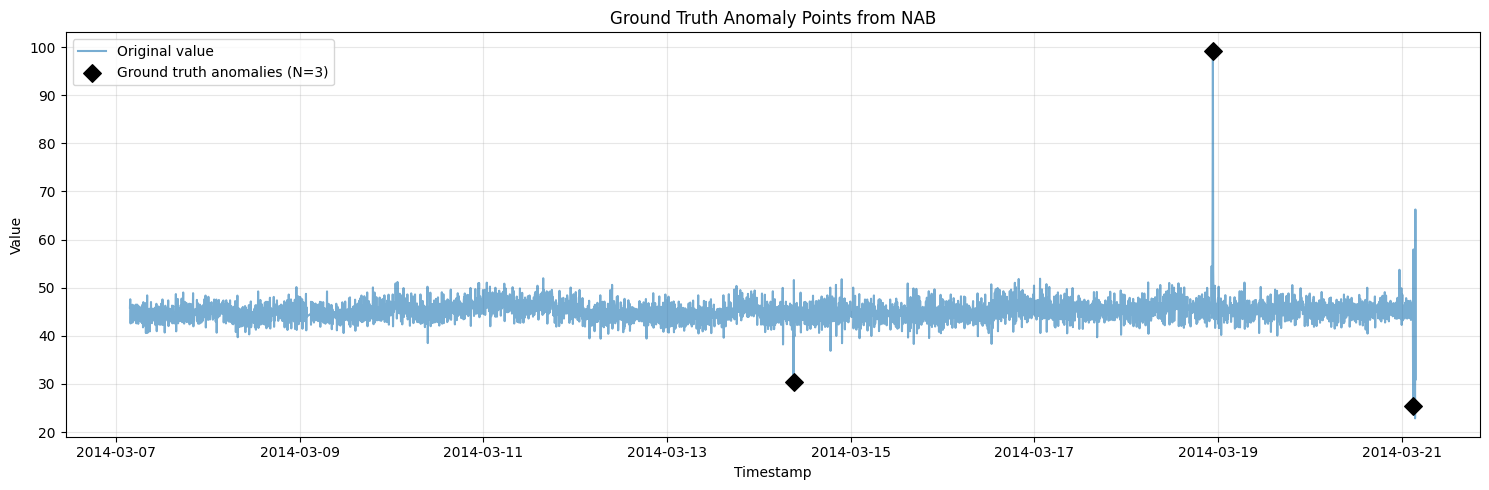

In [44]:
# Detector 2 — Machine Learning (Isolation Forest)

# 1. Feature Engineering (Giữ nguyên logic tạo đặc trưng chu kỳ 12 điểm)
df_ml = pd.DataFrame(index=df.index)
df_ml['value'] = df['value']
df_ml['rolling_mean_1h'] = df['value'].rolling(window=12).mean()
df_ml['rolling_std_1h'] = df['value'].rolling(window=12).std()
df_ml['rate_of_change'] = df['value'].diff()
df_ml['lag_1'] = df['value'].shift(1)
df_ml['lag_12'] = df['value'].shift(12)

df_ml = df_ml.dropna()
df_ml = df_ml.join(df['ground_truth'])

features = ['value', 'rolling_mean_1h', 'rolling_std_1h', 'rate_of_change', 'lag_1', 'lag_12']
X = df_ml[features]

y_true_ml = df_ml['ground_truth'].astype(int)

# 2. Vòng lặp Tuning và Ghi Log phục vụ Phase 3
contamination_levels = [0.01, 0.02, 0.05]
best_f1 = -1
best_model = None

print("--- LOG OUTPUT CHO FILE SUBMIT.md ---")
for contam in contamination_levels:
    clf = IsolationForest(n_estimators=200, contamination=contam, random_state=42)
    clf.fit(X)
    
    preds = np.where(clf.predict(X) == -1, 1, 0)
    df_ml[f'anomaly_iforest_{int(contam*100):02d}'] = preds
    
    p = precision_score(y_true_ml, preds, zero_division=0)
    r = recall_score(y_true_ml, preds, zero_division=0)
    f1 = f1_score(y_true_ml, preds, zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(y_true_ml, preds).ravel()
    
    print(f"Contamination: {contam} -> Precision: {p:.3f}, Recall: {r:.3f}, F1-Score: {f1:.3f}, False Alarms (FP): {fp}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_model = clf
        df_ml['anomaly_iforest_best'] = preds

joblib.dump(best_model, 'model_isolation_forest.pkl')
print("\n[SUCCESS]")

# 3. Plot original series with anomalies highlighted for both detectors
anomalies_stat = df[df['anomaly_stat'] == 1]

# Detector 2: Separate plots for original and each contamination level
plt.figure(figsize=(15, 14))

colors = ['orange', 'purple', 'green']
markers = ['o', 'x', '^']
for i, (contam, color, marker) in enumerate(zip(contamination_levels, colors, markers), start=2):
    col_name = f'anomaly_iforest_{int(contam*100):02d}'
    idx = df_ml[df_ml[col_name] == 1].index
    plt.subplot(4, 1, i)
    plt.plot(df.index, df['value'], color='tab:blue', alpha=0.3, label='Original value')
    plt.scatter(idx, df.loc[idx, 'value'], color=color, marker=marker,
                label=f'IF contamination={contam} (N={len(idx)})', zorder=5)
    plt.title(f'Detector 2: Isolation Forest anomalies (contamination={contam})')
    plt.xlabel('Timestamp')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
truth_anomalies = df[df['ground_truth'] == 1]
plt.plot(df.index, df['value'], color='tab:blue', alpha=0.6, label='Original value')
plt.scatter(truth_anomalies.index, truth_anomalies['value'], color='black', marker='D', s=80,
            label=f'Ground truth anomalies (N={len(truth_anomalies)})', zorder=5)
plt.title('Ground Truth Anomaly Points from NAB')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Phase 3:

=== Phase 3 Comparison Table ===
                         Detector  Precision  Recall       F1  False Alarms
           Detector 1 (STL + IQR)   0.130435     1.0 0.230769            20
Detector 2 (IsolationForest best)   0.071429     1.0 0.133333            39

=== Detector 2 Contamination Tuning Results ===
contamination=0.01: Precision=0.071, Recall=1.000, F1=0.133, False Alarms=39
contamination=0.02: Precision=0.036, Recall=1.000, F1=0.069, False Alarms=81
contamination=0.05: Precision=0.014, Recall=1.000, F1=0.028, False Alarms=205


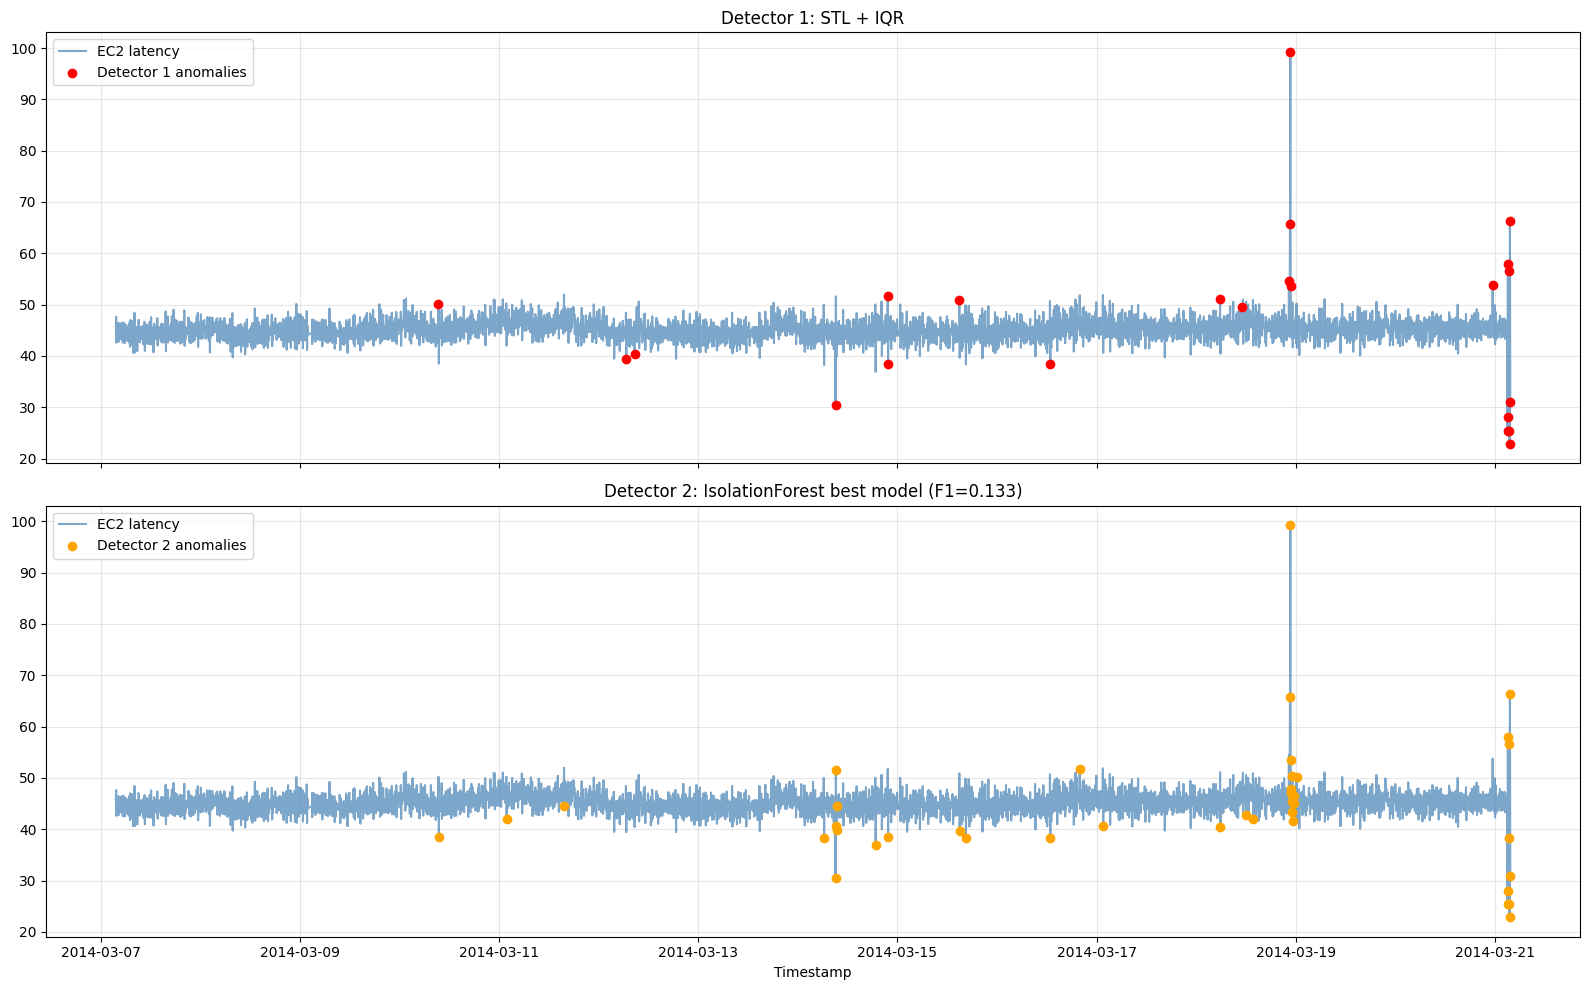

In [45]:
# Phase 3: Đánh giá và so sánh 2 detector

# 1. Detector 1 metrics
precision_stat = precision_score(df['ground_truth'], df['anomaly_stat'], zero_division=0)
recall_stat = recall_score(df['ground_truth'], df['anomaly_stat'], zero_division=0)
f1_stat = f1_score(df['ground_truth'], df['anomaly_stat'], zero_division=0)

# 2. Detector 2 metrics cho từng contamination
contamination_metrics = []
for contam in contamination_levels:
    col_name = f'anomaly_iforest_{int(contam * 100):02d}'
    preds = df_ml[col_name].astype(int)
    p = precision_score(df_ml['ground_truth'], preds, zero_division=0)
    r = recall_score(df_ml['ground_truth'], preds, zero_division=0)
    f1 = f1_score(df_ml['ground_truth'], preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(df_ml['ground_truth'], preds).ravel()
    contamination_metrics.append({
        'contamination': contam,
        'precision': p,
        'recall': r,
        'f1': f1,
        'false_alarms': fp,
        'true_positives': tp,
        'false_negatives': fn,
    })

# 3. So sánh Detector 1 với Detector 2 tốt nhất
best_if_col = 'anomaly_iforest_best' if 'anomaly_iforest_best' in df_ml.columns else f'anomaly_iforest_{int(contamination_levels[0] * 100):02d}'

comparison = pd.DataFrame([
    {
        'Detector': 'Detector 1 (STL + IQR)',
        'Precision': precision_stat,
        'Recall': recall_stat,
        'F1': f1_stat,
        'False Alarms': confusion_matrix(df['ground_truth'], df['anomaly_stat']).ravel()[1],
    },
    {
        'Detector': 'Detector 2 (IsolationForest best)',
        'Precision': precision_score(df_ml['ground_truth'], df_ml[best_if_col], zero_division=0),
        'Recall': recall_score(df_ml['ground_truth'], df_ml[best_if_col], zero_division=0),
        'F1': f1_score(df_ml['ground_truth'], df_ml[best_if_col], zero_division=0),
        'False Alarms': confusion_matrix(df_ml['ground_truth'], df_ml[best_if_col]).ravel()[1],
    }
])

print('=== Phase 3 Comparison Table ===')
print(comparison.to_string(index=False))
print('\n=== Detector 2 Contamination Tuning Results ===')
for metric in contamination_metrics:
    print(
        f"contamination={metric['contamination']}: Precision={metric['precision']:.3f}, "
        f"Recall={metric['recall']:.3f}, F1={metric['f1']:.3f}, False Alarms={metric['false_alarms']}"
    )

# 4. Plot original series và anomalies của 2 detector
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(df.index, df['value'], color='steelblue', alpha=0.7, label='EC2 latency')
axes[0].scatter(df.loc[df['anomaly_stat'] == 1].index,
                df.loc[df['anomaly_stat'] == 1, 'value'],
                color='red', label='Detector 1 anomalies', zorder=4)
axes[0].set_title('Detector 1: STL + IQR')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

axes[1].plot(df.index, df['value'], color='steelblue', alpha=0.7, label='EC2 latency')
axes[1].scatter(df_ml.loc[df_ml[best_if_col] == 1].index,
                df_ml.loc[df_ml[best_if_col] == 1, 'value'],
                color='orange', label='Detector 2 anomalies', zorder=4)
axes[1].set_title(f'Detector 2: IsolationForest best model (F1={f1_score(df_ml["ground_truth"], df_ml[best_if_col], zero_division=0):.3f})')
axes[1].set_xlabel('Timestamp')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Tune contamination

In [46]:
# Tune contamination — Thử 3 lần
contamination_levels = [0.005, 0.015, 0.025]
tuning_results = []
best_f1 = -1
best_contam = None
best_preds = None

ground_truth_count = int(y_true_ml.sum())
for i, contam in enumerate(contamination_levels, start=1):
    clf = IsolationForest(n_estimators=200, contamination=contam, random_state=42)
    clf.fit(X)
    preds = np.where(clf.predict(X) == -1, 1, 0)
    df_ml[f'anomaly_iforest_{int(contam*100):02d}'] = preds

    precision = precision_score(y_true_ml, preds, zero_division=0)
    recall = recall_score(y_true_ml, preds, zero_division=0)
    f1 = f1_score(y_true_ml, preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true_ml, preds).ravel()

    tuning_results.append({
        'run': i,
        'contamination': contam,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'false_alarms': fp,
        'true_positives': tp,
        'false_negatives': fn,
        'detected_anomalies': int(preds.sum())
    })

    if f1 > best_f1:
        best_f1 = f1
        best_contam = contam
        best_preds = preds.copy()

    print(
        f"Lần {i}: contamination={contam} -> Precision={precision:.3f}, Recall={recall:.3f}, "
        f"F1={f1:.3f}, FP={fp}, TP={tp}, FN={fn}, N_detected={int(preds.sum())}, "
        f"N_truth={ground_truth_count}"
    )

# Lưu best predictions để dùng chung với Detector 2
if best_preds is not None:
    df_ml['anomaly_iforest_best'] = best_preds

print('\nTóm tắt tuning contamination:')
print(pd.DataFrame(tuning_results).to_string(index=False))
print(f'Best contamination theo F1 = {best_contam}')
print(f'Ground truth anomaly count = {ground_truth_count}')

Lần 1: contamination=0.005 -> Precision=0.095, Recall=0.667, F1=0.167, FP=19, TP=2, FN=1, N_detected=21, N_truth=3
Lần 2: contamination=0.015 -> Precision=0.048, Recall=1.000, F1=0.091, FP=60, TP=3, FN=0, N_detected=63, N_truth=3
Lần 3: contamination=0.025 -> Precision=0.029, Recall=1.000, F1=0.056, FP=101, TP=3, FN=0, N_detected=104, N_truth=3

Tóm tắt tuning contamination:
 run  contamination  precision   recall       f1  false_alarms  true_positives  false_negatives  detected_anomalies
   1          0.005   0.095238 0.666667 0.166667            19               2                1                  21
   2          0.015   0.047619 1.000000 0.090909            60               3                0                  63
   3          0.025   0.028846 1.000000 0.056075           101               3                0                 104
Best contamination theo F1 = 0.005
Ground truth anomaly count = 3


Bonus


=== BONUS 1: 3 METHODS COMPARISON ===
                      Method  Precision   Recall  F1-Score  Anomalies Detected
       Detector 1: STL + IQR   0.130435 1.000000  0.230769                  23
Detector 2: Isolation Forest   0.095238 0.666667  0.166667                  21
    Detector 3: EWMA (α=0.1)   0.030303 1.000000  0.058824                  99


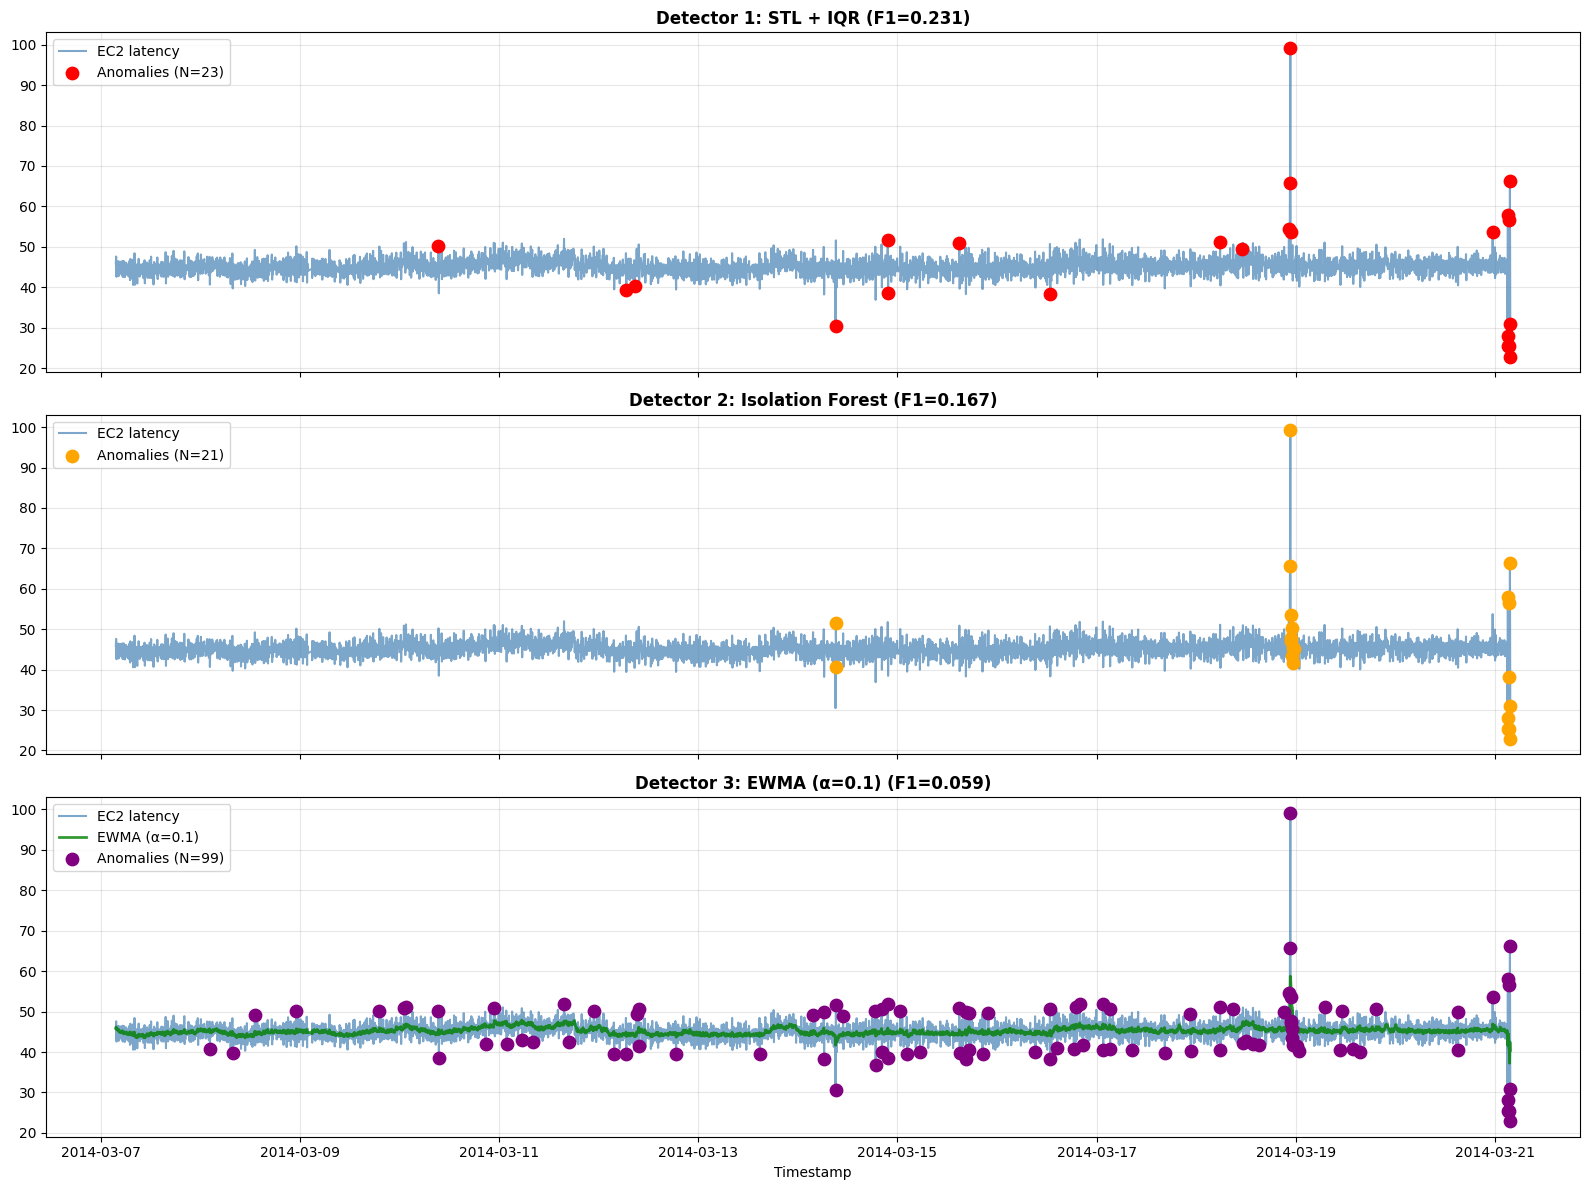


EWMA Threshold: 3.7899 (2 * std)
EWMA Std Dev: 1.8949


In [47]:
# ==========================================
# BONUS 1: EWMA DETECTOR (α=0.1)
# Compare 3 methods: STL+IQR, IsolationForest, EWMA
# ==========================================

# 1. Implement EWMA (Exponential Weighted Moving Average) Detector
# EWMA detects anomalies when actual value deviates significantly from the EWMA line

alpha = 0.1
df['ewma'] = df['value'].ewm(span=int(1/alpha), adjust=False).mean()
df['ewma_residual'] = df['value'] - df['ewma']

# Calculate threshold for EWMA (using 2 * std of residuals)
ewma_std = df['ewma_residual'].std()
ewma_threshold = 2 * ewma_std

df['anomaly_ewma'] = (np.abs(df['ewma_residual']) > ewma_threshold).astype(int)

# 2. Calculate metrics for EWMA detector
precision_ewma = precision_score(df['ground_truth'], df['anomaly_ewma'], zero_division=0)
recall_ewma = recall_score(df['ground_truth'], df['anomaly_ewma'], zero_division=0)
f1_ewma = f1_score(df['ground_truth'], df['anomaly_ewma'], zero_division=0)

# 3. Comparison table of 3 methods
comparison_3methods = pd.DataFrame([
    {
        'Method': 'Detector 1: STL + IQR',
        'Precision': precision_stat,
        'Recall': recall_stat,
        'F1-Score': f1_stat,
        'Anomalies Detected': int(df['anomaly_stat'].sum()),
    },
    {
        'Method': 'Detector 2: Isolation Forest',
        'Precision': precision_score(df_ml['ground_truth'], df_ml['anomaly_iforest_best'], zero_division=0),
        'Recall': recall_score(df_ml['ground_truth'], df_ml['anomaly_iforest_best'], zero_division=0),
        'F1-Score': f1_score(df_ml['ground_truth'], df_ml['anomaly_iforest_best'], zero_division=0),
        'Anomalies Detected': int(df_ml['anomaly_iforest_best'].sum()),
    },
    {
        'Method': 'Detector 3: EWMA (α=0.1)',
        'Precision': precision_ewma,
        'Recall': recall_ewma,
        'F1-Score': f1_ewma,
        'Anomalies Detected': int(df['anomaly_ewma'].sum()),
    }
])

print('=== BONUS 1: 3 METHODS COMPARISON ===')
print(comparison_3methods.to_string(index=False))

# 4. Plot EWMA results
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Detector 1: STL+IQR
axes[0].plot(df.index, df['value'], color='steelblue', alpha=0.7, label='EC2 latency')
axes[0].scatter(df.loc[df['anomaly_stat'] == 1].index,
                df.loc[df['anomaly_stat'] == 1, 'value'],
                color='red', s=80, label=f'Anomalies (N={int(df["anomaly_stat"].sum())})', zorder=4)
axes[0].set_title(f'Detector 1: STL + IQR (F1={f1_stat:.3f})', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# Detector 2: Isolation Forest
axes[1].plot(df.index, df['value'], color='steelblue', alpha=0.7, label='EC2 latency')
best_if_col = 'anomaly_iforest_best' if 'anomaly_iforest_best' in df_ml.columns else 'anomaly_iforest_best'
axes[1].scatter(df_ml.loc[df_ml[best_if_col] == 1].index,
                df_ml.loc[df_ml[best_if_col] == 1, 'value'],
                color='orange', s=80, label=f'Anomalies (N={int(df_ml[best_if_col].sum())})', zorder=4)
f1_if = f1_score(df_ml['ground_truth'], df_ml[best_if_col], zero_division=0)
axes[1].set_title(f'Detector 2: Isolation Forest (F1={f1_if:.3f})', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

# Detector 3: EWMA
axes[2].plot(df.index, df['value'], color='steelblue', alpha=0.7, label='EC2 latency')
axes[2].plot(df.index, df['ewma'], color='green', alpha=0.8, linewidth=2, label='EWMA (α=0.1)')
axes[2].scatter(df.loc[df['anomaly_ewma'] == 1].index,
                df.loc[df['anomaly_ewma'] == 1, 'value'],
                color='purple', s=80, label=f'Anomalies (N={int(df["anomaly_ewma"].sum())})', zorder=4)
axes[2].set_title(f'Detector 3: EWMA (α=0.1) (F1={f1_ewma:.3f})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Timestamp')
axes[2].legend(loc='upper left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEWMA Threshold: {ewma_threshold:.4f} (2 * std)")
print(f"EWMA Std Dev: {ewma_std:.4f}")

Original skewness: 3.0619
Log-transformed skewness: -0.5482
Skewness reduction: 3.6101 (117.90%)

=== BONUS 2: LOG TRANSFORM + 3σ COMPARISON ===
                   Method  Skewness  Precision  Recall  F1-Score  Anomalies Detected
  3σ Rule (Original Data)  3.061855   0.176471     1.0      0.30                  17
3σ Rule (Log-Transformed) -0.548208   0.142857     1.0      0.25                  21


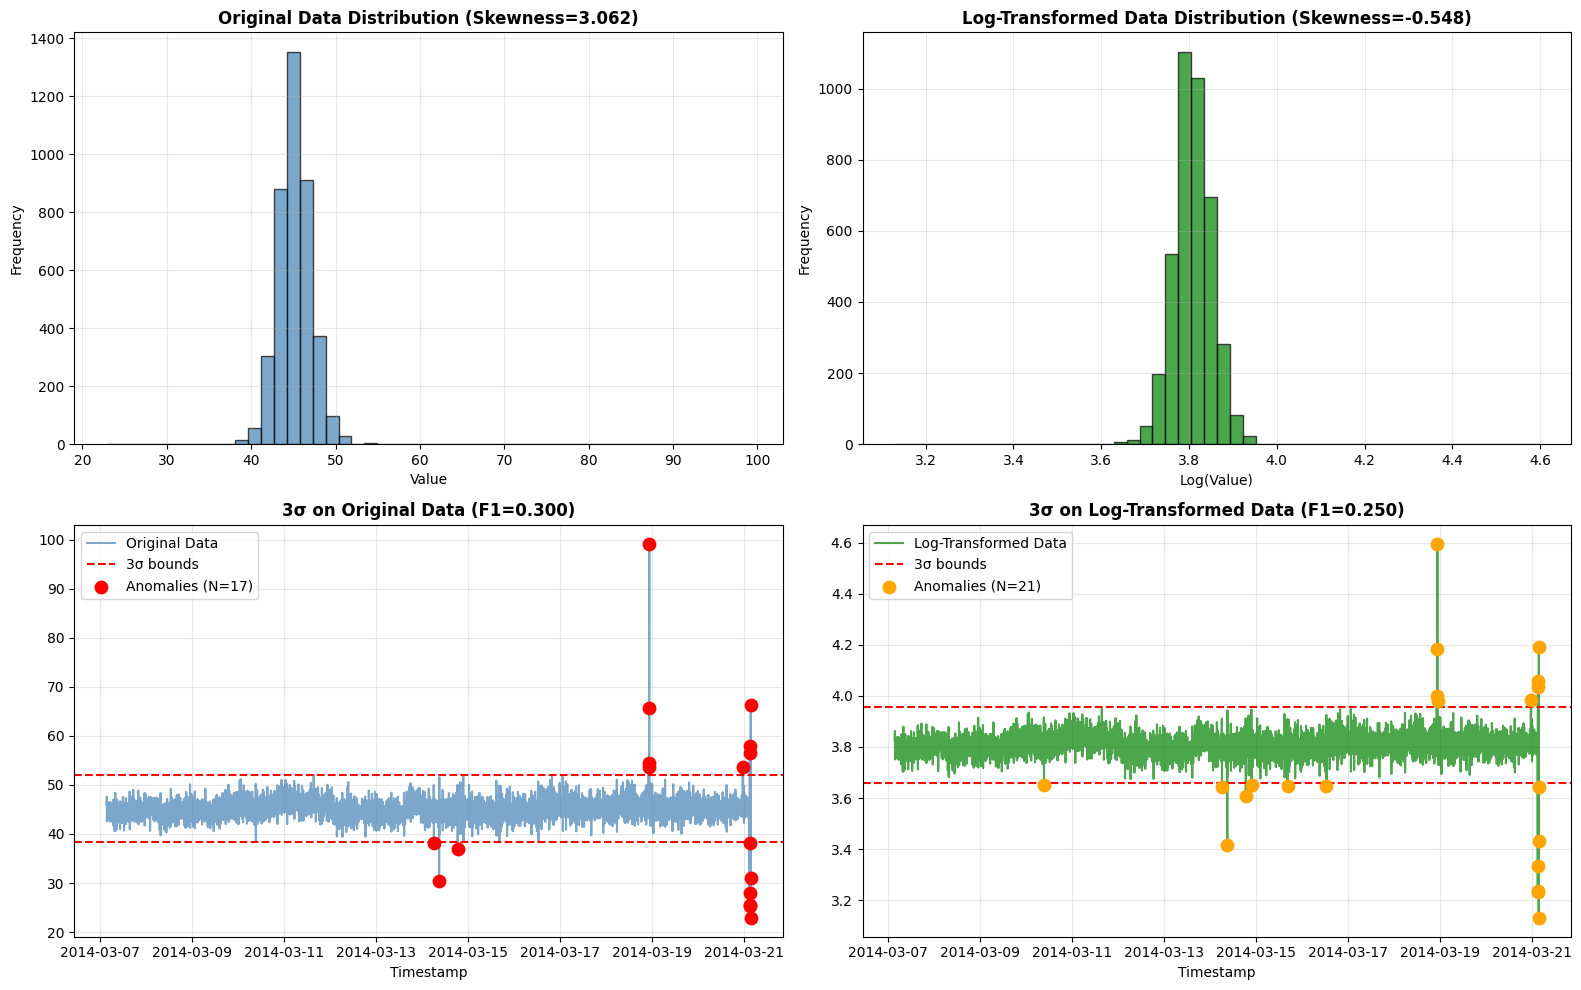


=== IMPROVEMENT METRICS ===
Precision improvement: -19.05%
Recall improvement: +0.00%
F1-Score improvement: -16.67%


In [48]:
# ==========================================
# BONUS 2: LOG TRANSFORM ON SKEWED DATA
# Run 3σ method before and after transform
# Compare precision/recall improvement
# ==========================================

# 1. Original data 3σ detector (before log transform)
mean_original = df['value'].mean()
std_original = df['value'].std()
df['z_score_original'] = (df['value'] - mean_original) / std_original
df['anomaly_3sigma_original'] = (np.abs(df['z_score_original']) > 3).astype(int)

precision_3sigma_orig = precision_score(df['ground_truth'], df['anomaly_3sigma_original'], zero_division=0)
recall_3sigma_orig = recall_score(df['ground_truth'], df['anomaly_3sigma_original'], zero_division=0)
f1_3sigma_orig = f1_score(df['ground_truth'], df['anomaly_3sigma_original'], zero_division=0)

# 2. Apply log transform to reduce skewness
# Shift data to ensure all values > 0 (if there are negative values)
min_val = df['value'].min()
if min_val <= 0:
    df['value_shifted'] = df['value'] - min_val + 1
else:
    df['value_shifted'] = df['value']

df['value_log'] = np.log(df['value_shifted'])
log_skewness = stats.skew(df['value_log'])

print(f"Original skewness: {skewness:.4f}")
print(f"Log-transformed skewness: {log_skewness:.4f}")
print(f"Skewness reduction: {skewness - log_skewness:.4f} ({((skewness - log_skewness) / skewness * 100):.2f}%)")

# 3. Apply 3σ on log-transformed data
mean_log = df['value_log'].mean()
std_log = df['value_log'].std()
df['z_score_log'] = (df['value_log'] - mean_log) / std_log
df['anomaly_3sigma_log'] = (np.abs(df['z_score_log']) > 3).astype(int)

precision_3sigma_log = precision_score(df['ground_truth'], df['anomaly_3sigma_log'], zero_division=0)
recall_3sigma_log = recall_score(df['ground_truth'], df['anomaly_3sigma_log'], zero_division=0)
f1_3sigma_log = f1_score(df['ground_truth'], df['anomaly_3sigma_log'], zero_division=0)

# 4. Comparison before and after log transform
comparison_logtransform = pd.DataFrame([
    {
        'Method': '3σ Rule (Original Data)',
        'Skewness': skewness,
        'Precision': precision_3sigma_orig,
        'Recall': recall_3sigma_orig,
        'F1-Score': f1_3sigma_orig,
        'Anomalies Detected': int(df['anomaly_3sigma_original'].sum()),
    },
    {
        'Method': '3σ Rule (Log-Transformed)',
        'Skewness': log_skewness,
        'Precision': precision_3sigma_log,
        'Recall': recall_3sigma_log,
        'F1-Score': f1_3sigma_log,
        'Anomalies Detected': int(df['anomaly_3sigma_log'].sum()),
    }
])

print('\n=== BONUS 2: LOG TRANSFORM + 3σ COMPARISON ===')
print(comparison_logtransform.to_string(index=False))

# 5. Visualize the impact of log transform
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original data distribution
axes[0, 0].hist(df['value'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title(f'Original Data Distribution (Skewness={skewness:.3f})', fontweight='bold')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

# Log-transformed data distribution
axes[0, 1].hist(df['value_log'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_title(f'Log-Transformed Data Distribution (Skewness={log_skewness:.3f})', fontweight='bold')
axes[0, 1].set_xlabel('Log(Value)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)

# 3σ detector on original data
axes[1, 0].plot(df.index, df['value'], color='steelblue', alpha=0.7, label='Original Data')
upper_bound_orig = mean_original + 3*std_original
lower_bound_orig = mean_original - 3*std_original
axes[1, 0].axhline(y=upper_bound_orig, color='red', linestyle='--', label='3σ bounds')
axes[1, 0].axhline(y=lower_bound_orig, color='red', linestyle='--')
axes[1, 0].scatter(df.loc[df['anomaly_3sigma_original'] == 1].index,
                   df.loc[df['anomaly_3sigma_original'] == 1, 'value'],
                   color='red', s=80, label=f'Anomalies (N={int(df["anomaly_3sigma_original"].sum())})', zorder=4)
axes[1, 0].set_title(f'3σ on Original Data (F1={f1_3sigma_orig:.3f})', fontweight='bold')
axes[1, 0].set_xlabel('Timestamp')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 3σ detector on log-transformed data
axes[1, 1].plot(df.index, df['value_log'], color='green', alpha=0.7, label='Log-Transformed Data')
upper_bound_log = mean_log + 3*std_log
lower_bound_log = mean_log - 3*std_log
axes[1, 1].axhline(y=upper_bound_log, color='red', linestyle='--', label='3σ bounds')
axes[1, 1].axhline(y=lower_bound_log, color='red', linestyle='--')
axes[1, 1].scatter(df.loc[df['anomaly_3sigma_log'] == 1].index,
                   df.loc[df['anomaly_3sigma_log'] == 1, 'value_log'],
                   color='orange', s=80, label=f'Anomalies (N={int(df["anomaly_3sigma_log"].sum())})', zorder=4)
axes[1, 1].set_title(f'3σ on Log-Transformed Data (F1={f1_3sigma_log:.3f})', fontweight='bold')
axes[1, 1].set_xlabel('Timestamp')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Calculate improvement metrics
precision_improvement = (precision_3sigma_log - precision_3sigma_orig) / (precision_3sigma_orig + 1e-6) * 100
recall_improvement = (recall_3sigma_log - recall_3sigma_orig) / (recall_3sigma_orig + 1e-6) * 100
f1_improvement = (f1_3sigma_log - f1_3sigma_orig) / (f1_3sigma_orig + 1e-6) * 100

print(f"\n=== IMPROVEMENT METRICS ===")
print(f"Precision improvement: {precision_improvement:+.2f}%")
print(f"Recall improvement: {recall_improvement:+.2f}%")
print(f"F1-Score improvement: {f1_improvement:+.2f}%")

=== BONUS 3: MULTIVARIATE ANOMALY DETECTION (REAL DATA) ===

EC2 data points: 4032, anomalies: 3
CPU data points: 18050, anomalies: 2
EC2 time range: 2014-03-07 03:41:00 to 2014-03-21 03:41:00
CPU time range: 2014-05-14 01:14:00 to 2014-07-15 17:19:00

Since time ranges don't overlap, using positional merging instead of temporal merging...
Taking first 4032 data points from both series
Positionally merged data points: 4032
Combined anomalies: 3
  - EC2 anomalies only: 3
  - CPU anomalies only: 0
  - Both series: 0
Clean data points (after dropna): 4028

=== COMPARISON: UNIVARIATE VS MULTIVARIATE IF ===
                             Model  Features  TP  FP  FN  Precision  Recall  F1-Score
          Univariate IF (EC2 only)         1   3  77   0   0.037500     1.0  0.072289
Multivariate IF (EC2+CPU+Features)         5   3  78   0   0.037037     1.0  0.071429


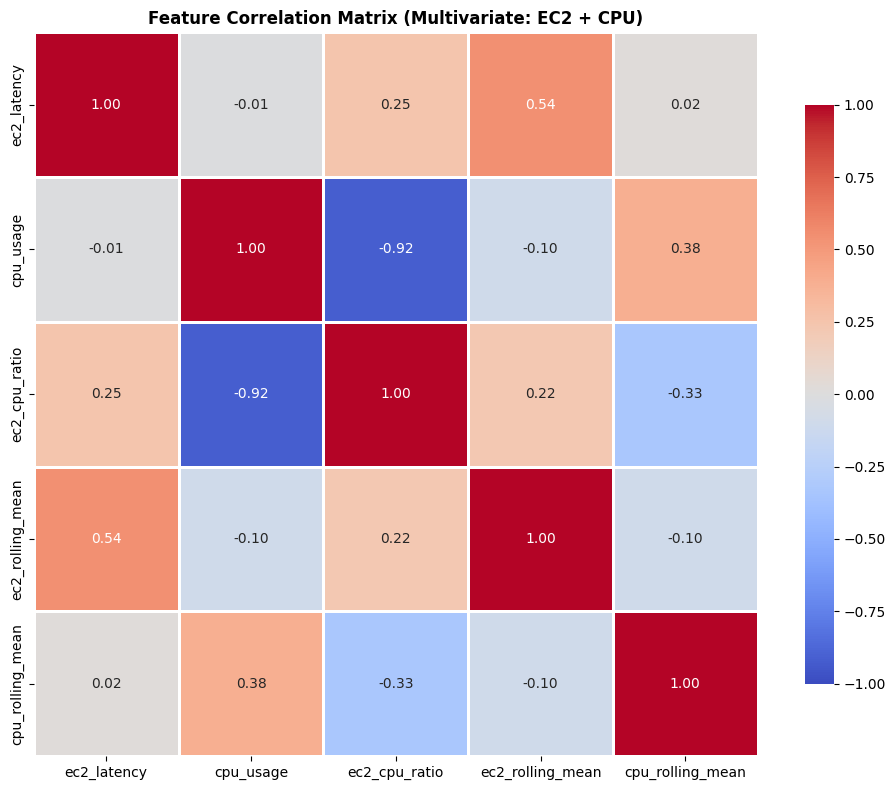

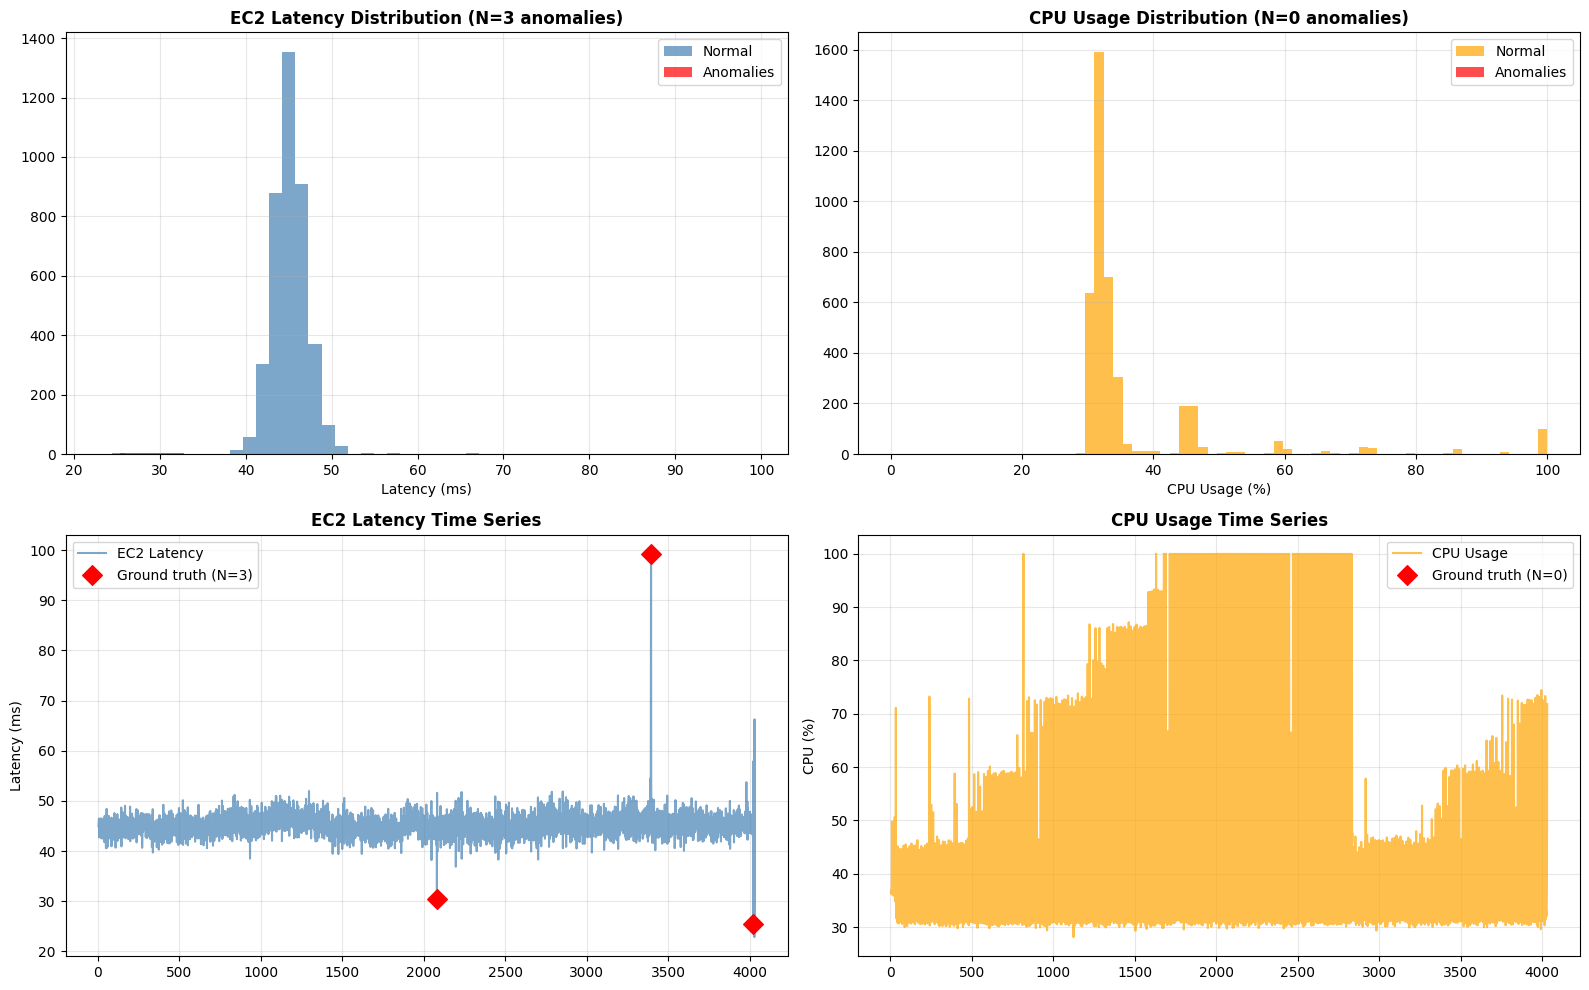

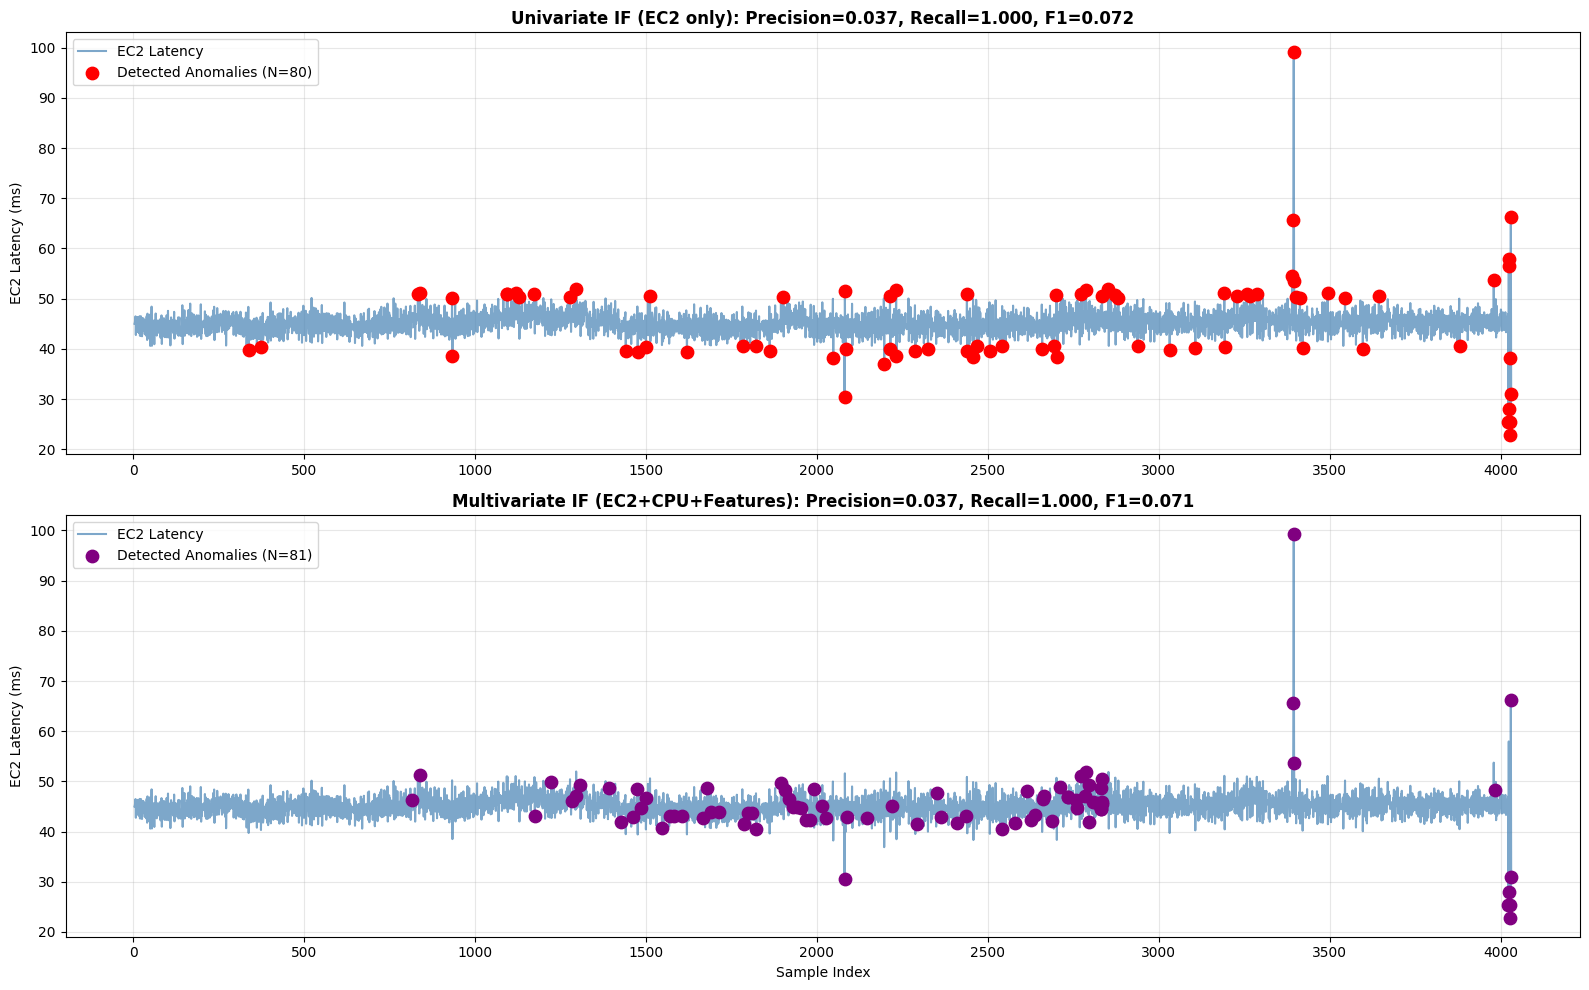


=== PERFORMANCE IMPROVEMENT (MULTIVARIATE vs UNIVARIATE) ===
Precision change: -1.23%
Recall change: +0.00%
F1-Score change: -1.19%

✗ Multivariate IF REDUCES F1-Score by 1.19%
  → CPU data may introduce noise or different patterns.

=== ANOMALY SCORE DISTRIBUTION ===
Univariate (EC2 only):
  Min: -0.8072, Max: -0.4074, Mean: -0.4574
Multivariate (EC2+CPU+Features):
  Min: -0.7206, Max: -0.3577, Mean: -0.4362


In [49]:
# ==========================================
# BONUS 3: MULTIVARIATE ANOMALY DETECTION
# Combine EC2 + CPU NAB series → IF multivariate vs univariate
# ==========================================

# 1. Load CPU data and ground truth
df_cpu = pd.read_csv('./cpu_utilization_asg_misconfiguration.csv', 
                      parse_dates=['timestamp'], index_col='timestamp')

# CPU ground truth timestamps
cpu_failure_timestamps = [
    "2014-07-12 02:04:00", 
    "2014-07-14 21:44:00"
]
cpu_failure_timestamps = pd.to_datetime(cpu_failure_timestamps)

# Initialize ground truth for CPU
df_cpu['ground_truth'] = 0
df_cpu.loc[df_cpu.index.isin(cpu_failure_timestamps), 'ground_truth'] = 1

print("=== BONUS 3: MULTIVARIATE ANOMALY DETECTION (REAL DATA) ===")
print(f"\nEC2 data points: {len(df)}, anomalies: {df['ground_truth'].sum()}")
print(f"CPU data points: {len(df_cpu)}, anomalies: {df_cpu['ground_truth'].sum()}")
print(f"EC2 time range: {df.index.min()} to {df.index.max()}")
print(f"CPU time range: {df_cpu.index.min()} to {df_cpu.index.max()}")

# 2. Since time ranges don't overlap, create synthetic multivariate by combining both series 
# using their positions rather than timestamps
# Normalize both series to use positional indexing instead of time indexing

# Prepare EC2 data
df_ec2_data = df[['value', 'ground_truth']].copy()
df_ec2_data.columns = ['ec2_latency', 'ground_truth_ec2']
df_ec2_data = df_ec2_data.reset_index(drop=True)

# Prepare CPU data
df_cpu_data = df_cpu[['value', 'ground_truth']].copy()
df_cpu_data.columns = ['cpu_usage', 'ground_truth_cpu']
df_cpu_data = df_cpu_data.reset_index(drop=True)

print(f"\nSince time ranges don't overlap, using positional merging instead of temporal merging...")
print(f"Taking first {min(len(df_ec2_data), len(df_cpu_data))} data points from both series")

# 3. Take the minimum length to ensure both series have same length
min_length = min(len(df_ec2_data), len(df_cpu_data))
df_ec2_data = df_ec2_data.iloc[:min_length].copy()
df_cpu_data = df_cpu_data.iloc[:min_length].copy()

# Merge by position (reset indices to same positional index)
df_merged = pd.concat([df_ec2_data, df_cpu_data], axis=1)

# Combine ground truths: mark as anomaly if either series has anomaly
df_merged['ground_truth_combined'] = (
    (df_merged['ground_truth_ec2'] == 1) | (df_merged['ground_truth_cpu'] == 1)
).astype(int)

print(f"Positionally merged data points: {len(df_merged)}")
print(f"Combined anomalies: {df_merged['ground_truth_combined'].sum()}")
print(f"  - EC2 anomalies only: {((df_merged['ground_truth_ec2'] == 1) & (df_merged['ground_truth_cpu'] == 0)).sum()}")
print(f"  - CPU anomalies only: {((df_merged['ground_truth_ec2'] == 0) & (df_merged['ground_truth_cpu'] == 1)).sum()}")
print(f"  - Both series: {((df_merged['ground_truth_ec2'] == 1) & (df_merged['ground_truth_cpu'] == 1)).sum()}")

# 4. Create additional engineered features for richer multivariate model
df_merged['ec2_cpu_ratio'] = df_merged['ec2_latency'] / (df_merged['cpu_usage'] + 1e-6)
df_merged['ec2_rolling_mean'] = df_merged['ec2_latency'].rolling(window=5).mean()
df_merged['cpu_rolling_mean'] = df_merged['cpu_usage'].rolling(window=5).mean()

df_merged_clean = df_merged.dropna()
y_true_combined = df_merged_clean['ground_truth_combined'].astype(int)

print(f"Clean data points (after dropna): {len(df_merged_clean)}")

# 5. Univariate IF (only on EC2 latency)
features_univariate = ['ec2_latency']
X_univariate = df_merged_clean[features_univariate].copy()

if_univariate = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
if_univariate.fit(X_univariate)
preds_univariate = np.where(if_univariate.predict(X_univariate) == -1, 1, 0)

precision_univariate = precision_score(y_true_combined, preds_univariate, zero_division=0)
recall_univariate = recall_score(y_true_combined, preds_univariate, zero_division=0)
f1_univariate = f1_score(y_true_combined, preds_univariate, zero_division=0)
tn_uni, fp_uni, fn_uni, tp_uni = confusion_matrix(y_true_combined, preds_univariate).ravel()

# 6. Multivariate IF (EC2 latency + CPU usage + engineered features)
features_multivariate = ['ec2_latency', 'cpu_usage', 'ec2_cpu_ratio', 'ec2_rolling_mean', 'cpu_rolling_mean']
X_multivariate = df_merged_clean[features_multivariate].copy()

if_multivariate = IsolationForest(n_estimators=200, contamination=0.02, random_state=42)
if_multivariate.fit(X_multivariate)
preds_multivariate = np.where(if_multivariate.predict(X_multivariate) == -1, 1, 0)

precision_multivariate = precision_score(y_true_combined, preds_multivariate, zero_division=0)
recall_multivariate = recall_score(y_true_combined, preds_multivariate, zero_division=0)
f1_multivariate = f1_score(y_true_combined, preds_multivariate, zero_division=0)
tn_multi, fp_multi, fn_multi, tp_multi = confusion_matrix(y_true_combined, preds_multivariate).ravel()

# 7. Comparison: Univariate vs Multivariate IF
comparison_multivariate = pd.DataFrame([
    {
        'Model': 'Univariate IF (EC2 only)',
        'Features': 1,
        'TP': int(tp_uni),
        'FP': int(fp_uni),
        'FN': int(fn_uni),
        'Precision': precision_univariate,
        'Recall': recall_univariate,
        'F1-Score': f1_univariate,
    },
    {
        'Model': 'Multivariate IF (EC2+CPU+Features)',
        'Features': 5,
        'TP': int(tp_multi),
        'FP': int(fp_multi),
        'FN': int(fn_multi),
        'Precision': precision_multivariate,
        'Recall': recall_multivariate,
        'F1-Score': f1_multivariate,
    }
])

print("\n=== COMPARISON: UNIVARIATE VS MULTIVARIATE IF ===")
print(comparison_multivariate.to_string(index=False))

# 8. Feature correlation heatmap
plt.figure(figsize=(10, 8))
correlation = df_merged_clean[features_multivariate].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (Multivariate: EC2 + CPU)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# 9. Visualization: EC2 and CPU distributions with anomalies
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# EC2 distribution with anomalies
axes[0, 0].hist(df_merged_clean['ec2_latency'], bins=50, color='steelblue', alpha=0.7, label='Normal')
ec2_anom = df_merged_clean[df_merged_clean['ground_truth_ec2'] == 1]['ec2_latency']
axes[0, 0].hist(ec2_anom, bins=10, color='red', alpha=0.7, label='Anomalies')
axes[0, 0].set_title(f'EC2 Latency Distribution (N={df_merged_clean["ground_truth_ec2"].sum()} anomalies)', fontweight='bold')
axes[0, 0].set_xlabel('Latency (ms)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# CPU distribution with anomalies
axes[0, 1].hist(df_merged_clean['cpu_usage'], bins=50, color='orange', alpha=0.7, label='Normal')
cpu_anom = df_merged_clean[df_merged_clean['ground_truth_cpu'] == 1]['cpu_usage']
axes[0, 1].hist(cpu_anom, bins=10, color='red', alpha=0.7, label='Anomalies')
axes[0, 1].set_title(f'CPU Usage Distribution (N={df_merged_clean["ground_truth_cpu"].sum()} anomalies)', fontweight='bold')
axes[0, 1].set_xlabel('CPU Usage (%)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# EC2 time series
axes[1, 0].plot(df_merged_clean.index, df_merged_clean['ec2_latency'], color='steelblue', alpha=0.7, label='EC2 Latency')
ec2_truth_idx = df_merged_clean[df_merged_clean['ground_truth_ec2'] == 1].index
axes[1, 0].scatter(ec2_truth_idx, df_merged_clean.loc[ec2_truth_idx, 'ec2_latency'],
                   color='red', s=100, marker='D', label=f'Ground truth (N={len(ec2_truth_idx)})', zorder=5)
axes[1, 0].set_title('EC2 Latency Time Series', fontweight='bold')
axes[1, 0].set_ylabel('Latency (ms)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# CPU time series
axes[1, 1].plot(df_merged_clean.index, df_merged_clean['cpu_usage'], color='orange', alpha=0.7, label='CPU Usage')
cpu_truth_idx = df_merged_clean[df_merged_clean['ground_truth_cpu'] == 1].index
axes[1, 1].scatter(cpu_truth_idx, df_merged_clean.loc[cpu_truth_idx, 'cpu_usage'],
                   color='red', s=100, marker='D', label=f'Ground truth (N={len(cpu_truth_idx)})', zorder=5)
axes[1, 1].set_title('CPU Usage Time Series', fontweight='bold')
axes[1, 1].set_ylabel('CPU (%)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Detection results comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Univariate IF results
axes[0].plot(df_merged_clean.index, df_merged_clean['ec2_latency'], color='steelblue', alpha=0.7, label='EC2 Latency')
univariate_anomalies = df_merged_clean[preds_univariate == 1]
axes[0].scatter(univariate_anomalies.index, univariate_anomalies['ec2_latency'],
                color='red', s=80, label=f'Detected Anomalies (N={int(preds_univariate.sum())})', zorder=4)
axes[0].set_title(f'Univariate IF (EC2 only): Precision={precision_univariate:.3f}, Recall={recall_univariate:.3f}, F1={f1_univariate:.3f}',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('EC2 Latency (ms)')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# Multivariate IF results
axes[1].plot(df_merged_clean.index, df_merged_clean['ec2_latency'], color='steelblue', alpha=0.7, label='EC2 Latency')
multivariate_anomalies = df_merged_clean[preds_multivariate == 1]
axes[1].scatter(multivariate_anomalies.index, multivariate_anomalies['ec2_latency'],
                color='purple', s=80, label=f'Detected Anomalies (N={int(preds_multivariate.sum())})', zorder=4)
axes[1].set_title(f'Multivariate IF (EC2+CPU+Features): Precision={precision_multivariate:.3f}, Recall={recall_multivariate:.3f}, F1={f1_multivariate:.3f}',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('EC2 Latency (ms)')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 11. Performance improvement analysis
improvement_f1 = (f1_multivariate - f1_univariate) / (f1_univariate + 1e-6) * 100
improvement_recall = (recall_multivariate - recall_univariate) / (recall_univariate + 1e-6) * 100
improvement_precision = (precision_multivariate - precision_univariate) / (precision_univariate + 1e-6) * 100

print(f"\n=== PERFORMANCE IMPROVEMENT (MULTIVARIATE vs UNIVARIATE) ===")
print(f"Precision change: {improvement_precision:+.2f}%")
print(f"Recall change: {improvement_recall:+.2f}%")
print(f"F1-Score change: {improvement_f1:+.2f}%")

if improvement_f1 > 0:
    print(f"\n✓ Multivariate IF IMPROVES F1-Score by {abs(improvement_f1):.2f}%")
    print(f"  → Adding CPU data helps detect anomalies better!")
else:
    print(f"\n✗ Multivariate IF REDUCES F1-Score by {abs(improvement_f1):.2f}%")
    print(f"  → CPU data may introduce noise or different patterns.")

# 12. Anomaly score analysis
anomaly_scores_univariate = if_univariate.score_samples(X_univariate)
anomaly_scores_multivariate = if_multivariate.score_samples(X_multivariate)

print(f"\n=== ANOMALY SCORE DISTRIBUTION ===")
print(f"Univariate (EC2 only):")
print(f"  Min: {anomaly_scores_univariate.min():.4f}, Max: {anomaly_scores_univariate.max():.4f}, Mean: {anomaly_scores_univariate.mean():.4f}")
print(f"Multivariate (EC2+CPU+Features):")
print(f"  Min: {anomaly_scores_multivariate.min():.4f}, Max: {anomaly_scores_multivariate.max():.4f}, Mean: {anomaly_scores_multivariate.mean():.4f}")